**Nama:** Bella Namira Syaidatulnissa
<br>**NIM:** 250401020083
<br>**Kelas:** IF405

In [2]:
import pandas as pd
df = pd.read_csv("/telco_churn.csv")
print(df.shape)
print(df["Churn"].value_counts(normalize=True))

(7043, 21)
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Identifikasi fitur kategorikal
categorical_features = df.select_dtypes(include=['object', 'category']).columns

# Lakukan One-Hot Encoding pada fitur kategorikal
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# Pisahkan X (fitur) dan y (target = Churn)
X = df_encoded.drop('Churn_Yes', axis=1) # Asumsi 'Churn_Yes' adalah hasil encoding dari 'Churn'
y = df_encoded['Churn_Yes']

X_tr, X_te, y_tr, y_te = train_test_split(
X, y, test_size=0.2, stratify=y, random_state=42)

In [4]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
n_estimators=300, class_weight="balanced", random_state=42)
rf.fit(X_tr, y_tr)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [5]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = rf.predict(X_te)
y_proba = rf.predict_proba(X_te)[:, 1] # probabilitas kelas positif (Churn)

print("Classification Report:")
print(classification_report(y_te, y_pred))

print("ROC-AUC Score:")
print(roc_auc_score(y_te, y_proba))

Classification Report:
              precision    recall  f1-score   support

       False       0.84      0.90      0.87      1035
        True       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC Score:
0.8337260068717869


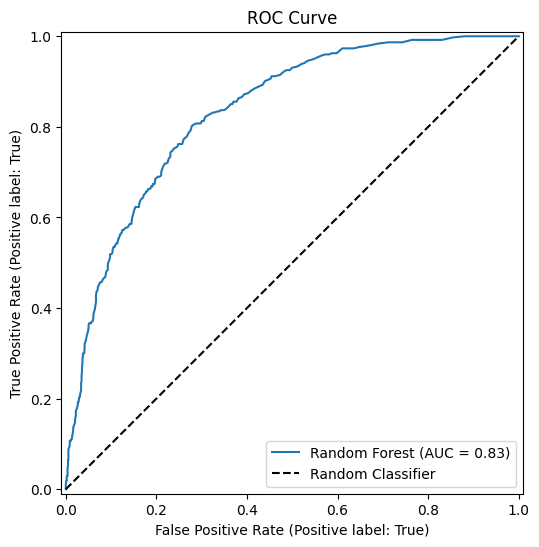

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(rf, X_te, y_te, ax=ax, name='Random Forest')
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_title('ROC Curve')
ax.legend()
plt.show()

### Ringkasan Interpretasi Metrik untuk Prediksi *Customer Churn* pada *Imbalanced Dataset*

Pada prediksi *customer churn* dengan dataset yang tidak seimbang, `Accuracy` seringkali membuat kebingungan karena dapat tinggi meskipun model gagal mengidentifikasi kelas minoritas (pelanggan *churn*).

**Metrik yang lebih relevan untuk kasus ini adalah:**

1.  **`Recall` (untuk kelas Churn)**: Mengukur seberapa baik model mengidentifikasi semua pelanggan yang *churn*. Cukup penting untuk meminimalkan *False Negatives* (pelanggan *churn* yang tidak terdeteksi) agar tidak kehilangan kesempatan intervensi.
2.  **`Precision` (untuk kelas Churn)**: Mengukur seberapa akurat prediksi *churn* model. Penting agar intervensi ditargetkan pada pelanggan yang benar-benar berisiko, menghindari pemborosan sumber daya.
3.  **`F1-Score` (untuk kelas Churn)**: Keseimbangan antara `Precision` dan `Recall`, memberikan gambaran kinerja model secara keseluruhan untuk kelas minoritas.
4.  **`ROC-AUC Score`**: Mengukur kemampuan diskriminasi model antara kelas *churn* dan non-*churn* di berbagai ambang batas. Ini adalah metrik yang kuat untuk *imbalanced dataset* karena tidak sensitif terhadap rasio kelas.

**Kesimpulan**: Untuk *customer churn*, fokus harus pada **`Recall`, `Precision`, `F1-Score` untuk kelas *churn*, dan `ROC-AUC Score`** untuk mendapatkan gambaran kinerja model yang akurat dan berguna secara bisnis, bukan hanya `Accuracy`.

Proyek ini bertujuan untuk mengembangkan model prediktif bagi fenomena customer churn pada dataset yang menunjukkan ketidakseimbangan kelas. Proses pembelajaran mencakup pemahaman mendalam mengenai implementasi algoritma klasifikasi ensemble, yakni Random Forest, serta strategi penanganan imbalanced dataset melalui penggunaan class_weight='balanced'.

Penekanan khusus diberikan pada evaluasi model menggunakan metrik yang relevan seperti Recall, Precision, F1-Score untuk kelas minoritas (churn), serta ROC-AUC Score, mengingat bahwa Accuracy dapat menyesatkan dalam konteks ini. Temuan utama menunjukkan bahwa model Random Forest yang dikembangkan berhasil mencapai ROC-AUC Score sebesar 0.83, mengindikasikan kapabilitas diskriminatif yang memadai.

Meskipun demikian, masih terdapat ruang untuk peningkatan, terutama dalam aspek Recall untuk kelas churn, yang mengarah pada pertanyaan lanjutan mengenai eksplorasi teknik penanganan imbalance atau feature engineering yang lebih canggih guna mengoptimalkan kinerja model lebih lanjut.